<a href="https://colab.research.google.com/github/amrita13/TacticalReadinessFOB/blob/main/ScenariospecificDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

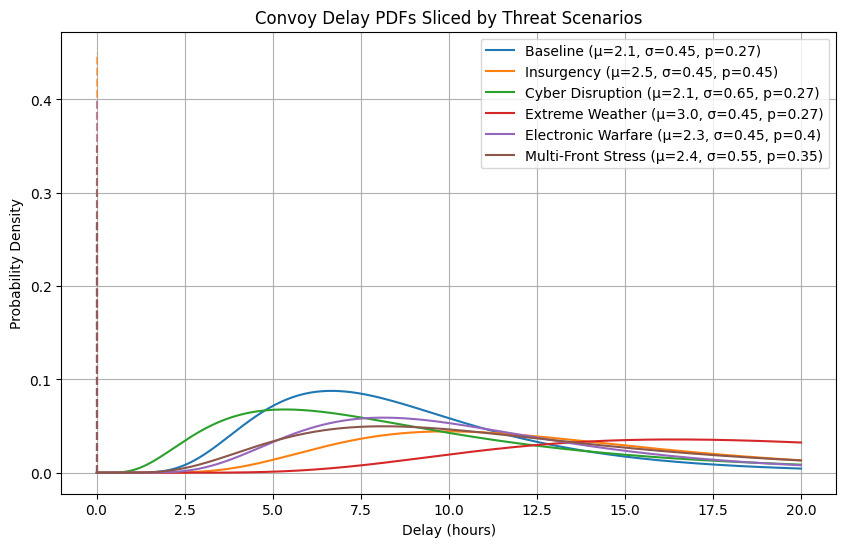

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ============================================================
# Convoy Delay Mixture Distribution
# ------------------------------------------------------------
# Each scenario is modeled as a mixture of:
#   - Lognormal(μ, σ): continuous convoy delay times
#   - Bernoulli(p): probability mass at zero (disruption event)
#
# Parameters:
#   μ (mu): mean of lognormal in log-space
#   σ (sigma): standard deviation in log-space
#   p: probability of zero delay (disruption)
#
# Threat scenarios adjust μ, σ, and p to reflect operational stress.
# ============================================================

scenarios = {
    # Baseline: natural convoy variability + occasional disruption
    "Baseline": {"mu": 2.1, "sigma": 0.45, "p": 0.27},

    # Insurgency: ambush/IEDs increase disruption probability and mean delay
    "Insurgency": {"mu": 2.5, "sigma": 0.45, "p": 0.45},

    # Cyber disruption: communication breakdown broadens variance (more unpredictable delays)
    "Cyber Disruption": {"mu": 2.1, "sigma": 0.65, "p": 0.27},

    # Extreme weather: terrain/floods increase mean delay (convoys consistently slower)
    "Extreme Weather": {"mu": 3.0, "sigma": 0.45, "p": 0.27},

    # Electronic warfare: jamming increases disruption probability + moderate delay shift
    "Electronic Warfare": {"mu": 2.3, "sigma": 0.45, "p": 0.40},

    # Multi-front stress: simultaneous threats increase both mean and variance
    "Multi-Front Stress": {"mu": 2.4, "sigma": 0.55, "p": 0.35}
}

# Range of delay values (hours)
x = np.linspace(0.01, 20, 500)

plt.figure(figsize=(10, 6))
for name, params in scenarios.items():
    mu, sigma, p = params["mu"], params["sigma"], params["p"]

    # Continuous lognormal PDF scaled by (1-p)
    pdf = (1 - p) * lognorm.pdf(x, s=sigma, scale=np.exp(mu))

    # Plot the continuous curve
    plt.plot(x, pdf, label=f"{name} (μ={mu}, σ={sigma}, p={p})")

    # Plot Bernoulli spike at zero (probability mass of disruption)
    plt.vlines(0, 0, p, colors=plt.gca().lines[-1].get_color(),
               linestyles="dashed", alpha=0.6)

plt.title("Convoy Delay PDFs Sliced by Threat Scenarios")
plt.xlabel("Delay (hours)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1149/1152418717.py:48: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf /= np.trapz(pdf, x)  # normalize to make it a proper PDF


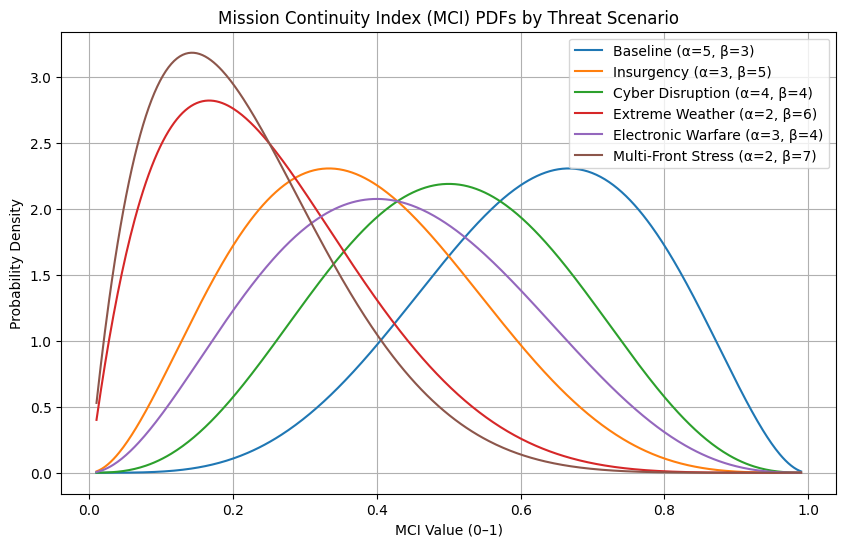

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Mission Continuity Index (MCI) Scenario Modeling
# ------------------------------------------------------------
# MCI ranges between 0 and 1, representing the ability of a FOB
# to sustain operations under stress.
#
# We model scenario-specific MCI distributions using Beta distributions,
# because Beta(α, β) naturally fits bounded [0,1] values.
#
# Parameters:
#   α (alpha): shape parameter controlling skew toward 1 (high continuity)
#   β (beta): shape parameter controlling skew toward 0 (low continuity)
#
# Each scenario adjusts α and β to reflect operational stress.
# ============================================================

scenarios = {
    # Baseline: moderate continuity, balanced distribution
    "Baseline": {"alpha": 5, "beta": 3},

    # Insurgency: frequent disruptions reduce continuity
    "Insurgency": {"alpha": 3, "beta": 5},

    # Cyber disruption: communication breakdown increases variance
    "Cyber Disruption": {"alpha": 4, "beta": 4},

    # Extreme weather: sustainment reliability drops, skew toward lower values
    "Extreme Weather": {"alpha": 2, "beta": 6},

    # Electronic warfare: jamming reduces continuity moderately
    "Electronic Warfare": {"alpha": 3, "beta": 4},

    # Multi-front stress: simultaneous threats heavily degrade continuity
    "Multi-Front Stress": {"alpha": 2, "beta": 7}
}

# Range of MCI values [0,1]
x = np.linspace(0.01, 0.99, 500)

plt.figure(figsize=(10, 6))
for name, params in scenarios.items():
    alpha, beta = params["alpha"], params["beta"]
    # Beta PDF
    pdf = (x**(alpha-1)) * ((1-x)**(beta-1))
    pdf /= np.trapz(pdf, x)  # normalize to make it a proper PDF

    plt.plot(x, pdf, label=f"{name} (α={alpha}, β={beta})")

plt.title("Mission Continuity Index (MCI) PDFs by Threat Scenario")
plt.xlabel("MCI Value (0–1)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

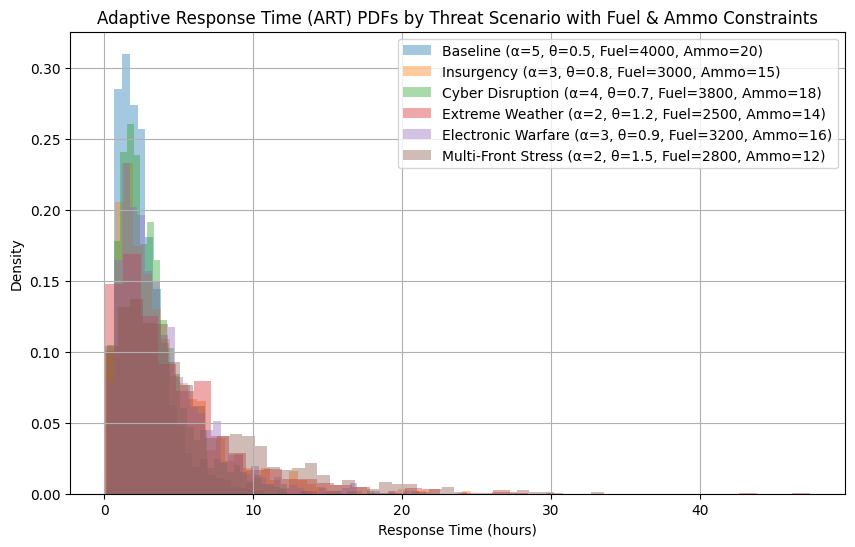

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, poisson

# ============================================================
# Adaptive Response Time (ART) Scenario Modeling
# ------------------------------------------------------------
# ART ~ Gamma(α, θ) baseline, modified by resource constraints.
# Fuel requirement ~ Gamma(k, θ_fuel)
# Ammunition consumption ~ Poisson(λ)
#
# Fuel shortage increases ART multiplicatively.
# Ammo shortage adds penalty to ART.
# ============================================================

# Scenario definitions: baseline ART parameters + resource stress
scenarios = {
    "Baseline": {"alpha": 5, "theta": 0.5, "fuel_avail": 4000, "ammo_avail": 20},
    "Insurgency": {"alpha": 3, "theta": 0.8, "fuel_avail": 3000, "ammo_avail": 15},
    "Cyber Disruption": {"alpha": 4, "theta": 0.7, "fuel_avail": 3800, "ammo_avail": 18},
    "Extreme Weather": {"alpha": 2, "theta": 1.2, "fuel_avail": 2500, "ammo_avail": 14},
    "Electronic Warfare": {"alpha": 3, "theta": 0.9, "fuel_avail": 3200, "ammo_avail": 16},
    "Multi-Front Stress": {"alpha": 2, "theta": 1.5, "fuel_avail": 2800, "ammo_avail": 12}
}

# Fuel requirement distribution (Gamma)
fuel_req = gamma.rvs(a=4.2, scale=950, size=1000)

# Ammunition consumption distribution (Poisson)
ammo_req = poisson.rvs(mu=18, size=1000)

x = np.linspace(0.01, 10, 500)
plt.figure(figsize=(10, 6))

for name, params in scenarios.items():
    alpha, theta = params["alpha"], params["theta"]
    fuel_avail, ammo_avail = params["fuel_avail"], params["ammo_avail"]

    # Baseline ART samples
    baseline_art = gamma.rvs(a=alpha, scale=theta, size=1000)

    # Fuel factor: higher when requirement exceeds availability
    fuel_factor = fuel_req / fuel_avail

    # Ammo penalty: proportional shortage
    ammo_penalty = 1 + np.maximum(0, (ammo_req - ammo_avail) / ammo_req)

    # Adjusted ART
    art_with_resources = baseline_art * fuel_factor * ammo_penalty

    # Plot histogram as density
    plt.hist(art_with_resources, bins=40, alpha=0.4, density=True,
             label=f"{name} (α={alpha}, θ={theta}, Fuel={fuel_avail}, Ammo={ammo_avail})")

plt.title("Adaptive Response Time (ART) PDFs by Threat Scenario with Fuel & Ammo Constraints")
plt.xlabel("Response Time (hours)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1149/1202068642.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_adjusted /= np.trapz(pdf_adjusted, x)  # re-normalize


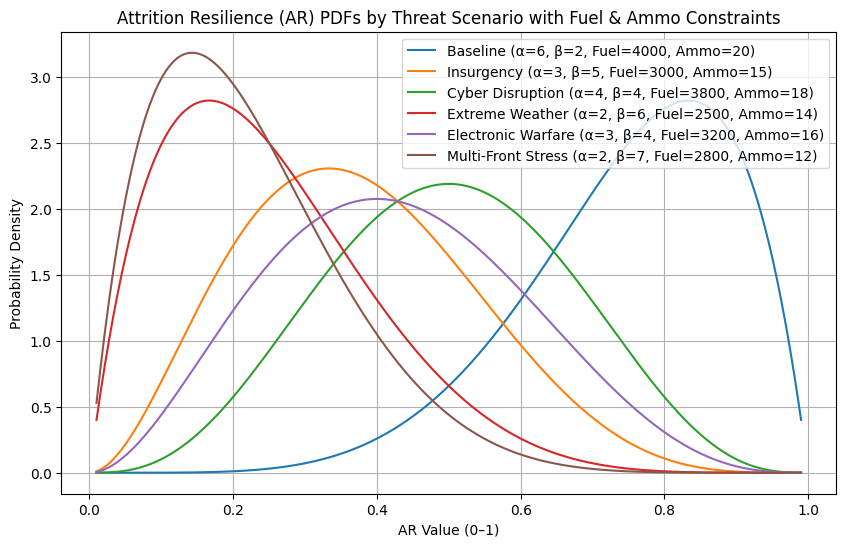

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# ============================================================
# Attrition Resilience (AR) Scenario Modeling
# ------------------------------------------------------------
# AR ranges between 0 and 1, representing ability to absorb losses.
# Modeled with Beta(α, β), flexible for bounded resilience values.
#
# Parameters:
#   α (alpha): skew toward resilience (closer to 1)
#   β (beta): skew toward fragility (closer to 0)
#
# Fuel and ammo shortages reduce AR further by scaling.
# ============================================================

scenarios = {
    "Baseline": {"alpha": 6, "beta": 2, "fuel_avail": 4000, "ammo_avail": 20},
    "Insurgency": {"alpha": 3, "beta": 5, "fuel_avail": 3000, "ammo_avail": 15},
    "Cyber Disruption": {"alpha": 4, "beta": 4, "fuel_avail": 3800, "ammo_avail": 18},
    "Extreme Weather": {"alpha": 2, "beta": 6, "fuel_avail": 2500, "ammo_avail": 14},
    "Electronic Warfare": {"alpha": 3, "beta": 4, "fuel_avail": 3200, "ammo_avail": 16},
    "Multi-Front Stress": {"alpha": 2, "beta": 7, "fuel_avail": 2800, "ammo_avail": 12}
}

# Range of AR values [0,1]
x = np.linspace(0.01, 0.99, 500)

plt.figure(figsize=(10, 6))
for name, params in scenarios.items():
    alpha, beta_param = params["alpha"], params["beta"]
    fuel_avail, ammo_avail = params["fuel_avail"], params["ammo_avail"]

    # Base Beta PDF
    pdf = beta.pdf(x, alpha, beta_param)

    # Resource scaling: resilience reduced if fuel/ammo below thresholds
    fuel_factor = fuel_avail / 4000   # normalize to baseline
    ammo_factor = ammo_avail / 20     # normalize to baseline
    resource_factor = (fuel_factor + ammo_factor) / 2

    # Adjusted PDF
    pdf_adjusted = pdf * resource_factor
    pdf_adjusted /= np.trapz(pdf_adjusted, x)  # re-normalize

    plt.plot(x, pdf_adjusted, label=f"{name} (α={alpha}, β={beta_param}, Fuel={fuel_avail}, Ammo={ammo_avail})")

plt.title("Attrition Resilience (AR) PDFs by Threat Scenario with Fuel & Ammo Constraints")
plt.xlabel("AR Value (0–1)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, gamma, poisson

# ============================================================
# Tactical Readiness Index (TRI) Scenario Modeling
# ------------------------------------------------------------
# TRI = α*DL* + β*MCI* + γ*ART* + δ*AR*
# where each component is normalized [0,1].
#
# DL ~ Lognormal + Bernoulli (convoy delay)
# MCI ~ Beta (mission continuity)
# ART ~ Gamma (adaptive response time, resource-aware)
# AR ~ Beta (attrition resilience, resource-aware)
#
# Fuel and ammo shortages feed into ART and AR.
# ============================================================

# Scenario definitions
scenarios = {
    "Baseline": {"mu_dl": 2.1, "sigma_dl": 0.45, "p_dl": 0.27,
                 "alpha_mci": 5, "beta_mci": 3,
                 "alpha_art": 5, "theta_art": 0.5,
                 "alpha_ar": 6, "beta_ar": 2,
                 "fuel_avail": 4000, "ammo_avail": 20},
    "Insurgency": {"mu_dl": 2.5, "sigma_dl": 0.45, "p_dl": 0.45,
                   "alpha_mci": 3, "beta_mci": 5,
                   "alpha_art": 3, "theta_art": 0.8,
                   "alpha_ar": 3, "beta_ar": 5,
                   "fuel_avail": 3000, "ammo_avail": 15},
    "Cyber Disruption": {"mu_dl": 2.1, "sigma_dl": 0.65, "p_dl": 0.27,
                         "alpha_mci": 4, "beta_mci": 4,
                         "alpha_art": 4, "theta_art": 0.7,
                         "alpha_ar": 4, "beta_ar": 4,
                         "fuel_avail": 3800, "ammo_avail": 18},
    "Extreme Weather": {"mu_dl": 3.0, "sigma_dl": 0.45, "p_dl": 0.27,
                        "alpha_mci": 2, "beta_mci": 6,
                        "alpha_art": 2, "theta_art": 1.2,
                        "alpha_ar": 2, "beta_ar": 6,
                        "fuel_avail": 2500, "ammo_avail": 14},
    "Electronic Warfare": {"mu_dl": 2.3, "sigma_dl": 0.45, "p_dl": 0.40,
                           "alpha_mci": 3, "beta_mci": 4,
                           "alpha_art": 3, "theta_art": 0.9,
                           "alpha_ar": 3, "beta_ar": 4,
                           "fuel_avail": 3200, "ammo_avail": 16},
    "Multi-Front Stress": {"mu_dl": 2.4, "sigma_dl": 0.55, "p_dl": 0.35,
                           "alpha_mci": 2, "beta_mci": 7,
                           "alpha_art": 2, "theta_art": 1.5,
                           "alpha_ar": 2, "beta_ar": 7,
                           "fuel_avail": 2800, "ammo_avail": 12}
}

# Fuel requirement distribution (Gamma)
fuel_req = gamma.rvs(a=4.2, scale=950, size=1000)
# Ammunition consumption distribution (Poisson)
ammo_req = poisson.rvs(mu=18, size=1000)

tri_means = {}

for name, params in scenarios.items():
    # --- DL ---
    dl_samples = (1 - params["p_dl"]) * lognorm.rvs(
        s=params["sigma_dl"], scale=np.exp(params["mu_dl"]), size=1000
    )
    dl_norm = (dl_samples - dl_samples.min()) / (dl_samples.max() - dl_samples.min())

    # --- MCI ---
    mci_samples = beta.rvs(params["alpha_mci"], params["beta_mci"], size=1000)

    # --- ART ---
    baseline_art = gamma.rvs(a=params["alpha_art"], scale=params["theta_art"], size=1000)
    fuel_factor = fuel_req / params["fuel_avail"]
    ammo_penalty = 1 + np.maximum(0, (ammo_req - params["ammo_avail"]) / ammo_req)
    art_samples = baseline_art * fuel_factor * ammo_penalty
    art_norm = (art_samples - art_samples.min()) / (art_samples.max() - art_samples.min())

    # --- AR ---
    ar_samples = beta.rvs(params["alpha_ar"], params["beta_ar"], size=1000)
    resource_factor = ((params["fuel_avail"]/4000) + (params["ammo_avail"]/20)) / 2
    ar_samples = ar_samples * resource_factor
    ar_norm = (ar_samples - ar_samples.min()) / (ar_samples.max() - ar_samples.min())

    # --- TRI (equal weights for simplicity) ---
    tri = 0.25*dl_norm + 0.25*mci_samples + 0.25*art_norm + 0.25*ar_norm
    tri_means[name] = np.mean(tri)

# Print scenario-specific TRI means
for scenario, tri_val in tri_means.items():
    print(f"{scenario}: TRI ≈ {tri_val:.3f}")

Baseline: TRI ≈ 0.425
Insurgency: TRI ≈ 0.284
Cyber Disruption: TRI ≈ 0.325
Extreme Weather: TRI ≈ 0.218
Electronic Warfare: TRI ≈ 0.310
Multi-Front Stress: TRI ≈ 0.198


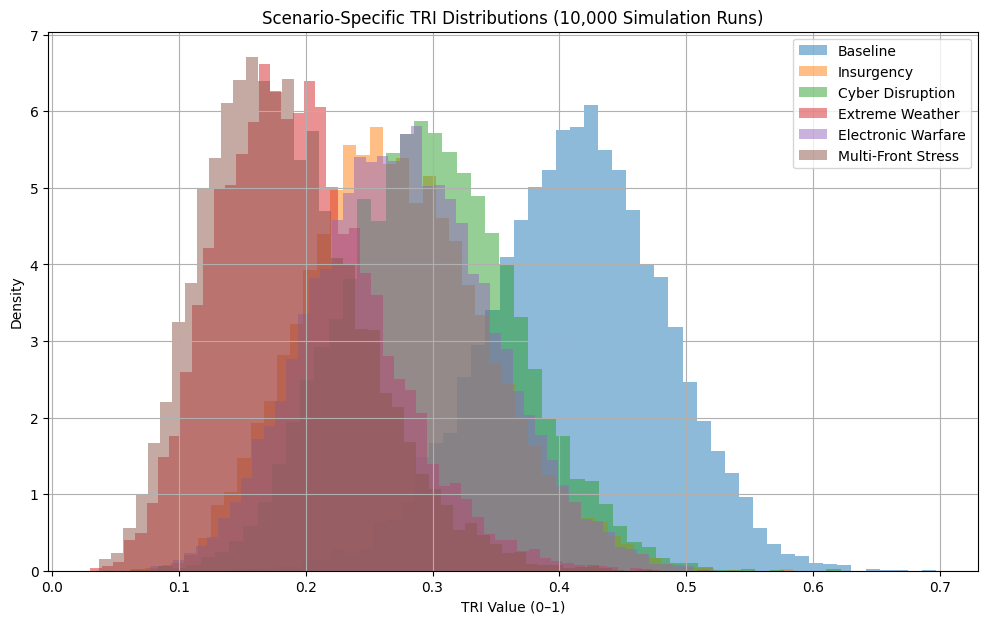

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, gamma, poisson

# ============================================================
# Tactical Readiness Index (TRI) Scenario Simulation
# ------------------------------------------------------------
# Components:
#   DL ~ Lognormal + Bernoulli
#   MCI ~ Beta
#   ART ~ Gamma (resource-aware)
#   AR ~ Beta (resource-aware)
#
# TRI = weighted composite of normalized components
# ============================================================

scenarios = {
    "Baseline": {"mu_dl": 2.1, "sigma_dl": 0.45, "p_dl": 0.27,
                 "alpha_mci": 5, "beta_mci": 3,
                 "alpha_art": 5, "theta_art": 0.5,
                 "alpha_ar": 6, "beta_ar": 2,
                 "fuel_avail": 4000, "ammo_avail": 20},
    "Insurgency": {"mu_dl": 2.5, "sigma_dl": 0.45, "p_dl": 0.45,
                   "alpha_mci": 3, "beta_mci": 5,
                   "alpha_art": 3, "theta_art": 0.8,
                   "alpha_ar": 3, "beta_ar": 5,
                   "fuel_avail": 3000, "ammo_avail": 15},
    "Cyber Disruption": {"mu_dl": 2.1, "sigma_dl": 0.65, "p_dl": 0.27,
                         "alpha_mci": 4, "beta_mci": 4,
                         "alpha_art": 4, "theta_art": 0.7,
                         "alpha_ar": 4, "beta_ar": 4,
                         "fuel_avail": 3800, "ammo_avail": 18},
    "Extreme Weather": {"mu_dl": 3.0, "sigma_dl": 0.45, "p_dl": 0.27,
                        "alpha_mci": 2, "beta_mci": 6,
                        "alpha_art": 2, "theta_art": 1.2,
                        "alpha_ar": 2, "beta_ar": 6,
                        "fuel_avail": 2500, "ammo_avail": 14},
    "Electronic Warfare": {"mu_dl": 2.3, "sigma_dl": 0.45, "p_dl": 0.40,
                           "alpha_mci": 3, "beta_mci": 4,
                           "alpha_art": 3, "theta_art": 0.9,
                           "alpha_ar": 3, "beta_ar": 4,
                           "fuel_avail": 3200, "ammo_avail": 16},
    "Multi-Front Stress": {"mu_dl": 2.4, "sigma_dl": 0.55, "p_dl": 0.35,
                           "alpha_mci": 2, "beta_mci": 7,
                           "alpha_art": 2, "theta_art": 1.5,
                           "alpha_ar": 2, "beta_ar": 7,
                           "fuel_avail": 2800, "ammo_avail": 12}
}

# Simulation size
N = 10000

# Fuel requirement distribution (Gamma)
fuel_req = gamma.rvs(a=4.2, scale=950, size=N)
# Ammunition consumption distribution (Poisson)
ammo_req = poisson.rvs(mu=18, size=N)

tri_results = {}

for name, params in scenarios.items():
    # --- DL ---
    dl_samples = (1 - params["p_dl"]) * lognorm.rvs(
        s=params["sigma_dl"], scale=np.exp(params["mu_dl"]), size=N
    )
    dl_norm = (dl_samples - dl_samples.min()) / (dl_samples.max() - dl_samples.min())

    # --- MCI ---
    mci_samples = beta.rvs(params["alpha_mci"], params["beta_mci"], size=N)

    # --- ART ---
    baseline_art = gamma.rvs(a=params["alpha_art"], scale=params["theta_art"], size=N)
    fuel_factor = fuel_req / params["fuel_avail"]
    ammo_penalty = 1 + np.maximum(0, (ammo_req - params["ammo_avail"]) / ammo_req)
    art_samples = baseline_art * fuel_factor * ammo_penalty
    art_norm = (art_samples - art_samples.min()) / (art_samples.max() - art_samples.min())

    # --- AR ---
    ar_samples = beta.rvs(params["alpha_ar"], params["beta_ar"], size=N)
    resource_factor = ((params["fuel_avail"]/4000) + (params["ammo_avail"]/20)) / 2
    ar_samples = ar_samples * resource_factor
    ar_norm = (ar_samples - ar_samples.min()) / (ar_samples.max() - ar_samples.min())

    # --- TRI (equal weights) ---
    tri = 0.25*dl_norm + 0.25*mci_samples + 0.25*art_norm + 0.25*ar_norm
    tri_results[name] = tri

# Plot scenario-specific TRI distributions
plt.figure(figsize=(12, 7))
for name, tri in tri_results.items():
    plt.hist(tri, bins=50, alpha=0.5, density=True, label=name)

plt.title("Scenario-Specific TRI Distributions (10,000 Simulation Runs)")
plt.xlabel("TRI Value (0–1)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()